## Data cleaning and preparation of the Simplified Device FingerPrint (SDFP)

In [1]:
import cheminfo_functions as cheminfo 
import qsar_functions as qsar
import data_prep_functions as prep

import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import re

### Co-Adsorbent

In [8]:
#First we load the raw dataset and seperate the Co-adsorbent column into type and concentration
dssc_db = pd.read_csv('Data/rawDSSCDBdata.csv')
dssc_db['Co_Adsorb_Type'], dssc_db['Co_Adsorb_Conc(mM)'] = zip(*dssc_db['Co-adsorbent'].apply(prep.clean_coadsorbent))

# Normalize whitespace
dssc_db['Co_Adsorb_Type'] = dssc_db['Co_Adsorb_Type'].str.replace(r'\s+', ' ', regex=True).str.strip()

#Clean Co_Adsorb_Type
coad_replace = {"chenodeoxycholic acid": "CDCA", 
                "3a,7a-dihydroxy-5b-cholic acid": "CDCA",
                "tetrabutylammonium Deoxycholate" :"DCA",
                "deoxycholate": "DCA",
                "1-decylphosphonic Acid": "1-decylphosphonic acid",
                "CCCC[C@@H](COc1ccc(cc1)c1ccc2c(c1)Sc1c(N2c2ccc(cc2)C(=O)O)ccc(c1)c1ccc(cc1)OC[C@H](CCCC)CC)CC": "PTZ1",
                "CCCC[C@@H](COc1ccc(cc1)c1ccc2c(c1)Sc1c(N2[C@@H]2CC=C(C=C2)c2ccc(cc2)C(=O)O)ccc(c1)c1ccc(cc1)OC[C@H](CCCC)CC)CC": "PTZ2",
                "CC1(C2=CC=CC=C2C=2C=CC(=CC12)N(C1=CC=C(C(=O)O)C=C1)C1=CC=2C(C3=CC=CC=C3C2C=C1)(C)C)C": "HC-A4",
                "C(C)C(COC1=CC=C(C=C1)C=1C=CC=2N(C3=CC=C(C=C3C2C1)C1=CC=C(C=C1)OCC(CCCC)CC)C1=CC=C(C(=O)O)C=C1)CCCC": "HC-A1",
                "HC-A": "HC-A1"
                }
dssc_db['Co_Adsorb_Type'] = dssc_db['Co_Adsorb_Type'].replace(coad_replace)

# Set the concentration to 0 wherever the type is '-'
dssc_db.loc[dssc_db['Co_Adsorb_Type'] == "-", 'Co_Adsorb_Conc(mM)'] = 0

# Replace '-' with nan value
dssc_db['Co_Adsorb_Type'] = dssc_db['Co_Adsorb_Type'].replace({"-":np.nan})

# Create Dataframe of One-Hot encoding of the Co_Adsorb_Type
co_ads_onehot = pd.get_dummies(dssc_db['Co_Adsorb_Type'], prefix='Co_Adsorb_Type', sparse=False, dtype=int)

 #Standardize Co-Adsorbent concentration
dssc_db["Co_Adsorb_Conc(mM)"] = dssc_db["Co_Adsorb_Conc(mM)"].apply(prep.standardize_saturation)

# Impute NaN values
dssc_db["Co_Adsorb_Conc(mM)"] = dssc_db["Co_Adsorb_Conc(mM)"].replace({np.nan: 5.12})

# Create Dataframe for later use
coad_conc = pd.DataFrame(dssc_db["Co_Adsorb_Conc(mM)"].copy())
coad_conc

-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False False False - nan
-
raw value []
False Fals

,Co_Adsorb_Conc(mM)
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
4421,0.0
4422,0.0
4423,0.0
4424,0.0


### Electrolyte

In [9]:
electrolyte_comparison = pd.DataFrame(dssc_db['Electrolyte'])
electrolyte_comparison['Electrolyte New'] = electrolyte_comparison['Electrolyte'].apply(prep.clean_electrolyte)
electrolyte_comparison

,Electrolyte,Electrolyte New
0,0.6 M 1-methyl-3-propylimidazolium iodide (PMI...,Iodide_Triiodide
1,"0.17 M Spiro-MeOTAD, 0.11 mM tert-butylpyridin...",Spiro-OMeTAD
2,"0.17 M Spiro-MeOTAD, 0.11 mM tert-butylpyridin...",Spiro-OMeTAD
3,"0.17 M Spiro-MeOTAD, 0.11 mM tert-butylpyridin...",Spiro-OMeTAD
4,"1,3-dimethylimidazolium iodide, 1-ethyl-3methy...",Iodide_Triiodide
...,...,...
4421,0.6 M 1-methyl-3-propylimidazolium iodide (PMI...,Iodide_Triiodide
4422,0.6 M 1-methyl-3-propylimidazolium iodide (PMI...,Iodide_Triiodide
4423,0.6 M 1-methyl-3-propylimidazolium iodide (PMI...,Iodide_Triiodide
4424,0.6 M 1-methyl-3-propylimidazolium iodide (PMI...,Iodide_Triiodide


In [10]:
electolyte_binarized = pd.get_dummies(electrolyte_comparison["Electrolyte New"], prefix="Electrolyte", dtype=int, dummy_na=True)
electolyte_binarized

,Electrolyte_Bromide_Tribromide,Electrolyte_Co(II)_Co(III),Electrolyte_Cu(I)_Cu(II),"Electrolyte_DHS-Z23, Heptachroma",Electrolyte_DMPIC_DMPIDC,Electrolyte_Dyesol Mixes,"Electrolyte_EMISCN, K(SeCN)3, GuanThio, NMB",Electrolyte_H2PtCl6·6H2O,Electrolyte_Iodide_Triiodide,Electrolyte_SCN-,Electrolyte_Spiro-OMeTAD,Electrolyte_solid,Electrolyte_nan
0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4421,0,0,0,0,0,0,0,0,1,0,0,0,0
4422,0,0,0,0,0,0,0,0,1,0,0,0,0
4423,0,0,0,0,0,0,0,0,1,0,0,0,0
4424,0,0,0,0,0,0,0,0,1,0,0,0,0


### Semiconductor

In [11]:
semicond_comparison = pd.DataFrame(dssc_db['Semiconductor'])
parsed = semicond_comparison['Semiconductor'].apply(prep.parse_semiconductor).apply(pd.Series)
result = pd.concat([semicond_comparison, parsed], axis=1)

In [12]:
semicond_type_binarized = pd.get_dummies(result["type"], prefix="SemiCond", dtype=int)
semicond_type_binarized

,SemiCond_NiO,SemiCond_SnO2,SemiCond_TiO2,SemiCond_Zn2SnO4,SemiCond_ZnO,SemiCond_zinc
0,0,0,1,0,0,0
1,0,0,1,0,0,0
2,0,0,1,0,0,0
3,0,0,1,0,0,0
4,0,0,1,0,0,0
...,...,...,...,...,...,...
4421,0,0,1,0,0,0
4422,0,0,1,0,0,0
4423,0,0,1,0,0,0
4424,0,0,1,0,0,0


In [13]:
semicond_cont = result[['film_thickness_um', 'scattering_thickness_um']].copy()
semicond_cont

,film_thickness_um,scattering_thickness_um
0,NaN,NaN
1,8.0,5.0
2,8.0,5.0
3,8.0,5.0
4,8.0,5.0
...,...,...
4421,14.0,NaN
4422,14.0,NaN
4423,14.0,NaN
4424,14.0,NaN


### Co-Sensitizer

In [14]:
dssc_db['Co-sensitizer'].value_counts()

Co-sensitizer
-                                 4316
N719                                12
C1                                  12
WS-5                                10
FNE46 cosensitizer                   7
Zn-3                                 7
Y123                                 6
D35                                  5
XW4                                  4
S2                                   4
TC2                                  4
TC1                                  4
N719, Ruthenium                      2
IQ21                                 2
XS-3                                 2
triphenylamine                       2
D149/D131                            2
Zinc-porphyrin as cosensitizer       1
SQ2                                  1
D3                                   1
0.025 mM D35                         1
0.025 mM NT35                        1
0.69e-04 mol/cm3                     1
0.93e-04 mol/cm3                     1
0.99e-04 mol/cm3                     1
0.73e-04 mo

In [15]:
cosens_comparison = pd.DataFrame(dssc_db['Co-sensitizer'])
cosens_comparison['Co_Sens'] = dssc_db['Co-sensitizer'].apply(prep.clean_cosensitizer)
cosens_binarized = pd.get_dummies(cosens_comparison['Co_Sens'] , prefix="Co_Sens", dtype=int)
cosens_binarized

,Co_Sens_C1,Co_Sens_D-205,Co_Sens_D131,Co_Sens_D149,Co_Sens_D149/D131,Co_Sens_D3,Co_Sens_D35,Co_Sens_D35 dye,Co_Sens_D35+HD2-mono,Co_Sens_FNE46 cosensitizer,...,Co_Sens_TC1,Co_Sens_TC2,Co_Sens_WS-5,Co_Sens_XS-3,Co_Sens_XW4,Co_Sens_Y123,Co_Sens_Zinc-porphyrin as cosensitizer,Co_Sens_Zn-3,Co_Sens_bodipy,Co_Sens_triphenylamine
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4421,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4422,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4423,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4424,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Active area (cm2), Exposure time (h), Solar simulator at 1.5G (mW/cm2), Dye loading (nmol/cm2)

In [16]:
active_area_cm2 = pd.DataFrame(dssc_db['Active area'].copy())
active_area_cm2.value_counts()

Active area
0.25           1006
0.16            927
-               745
0.159           253
0.2             213
               ... 
0.413             1
0.402             1
0.461             1
0.466             1
0.457             1
Name: count, Length: 78, dtype: int64

In [17]:
active_area_cm2['Active_area_cm2'] = active_area_cm2['Active area'].apply(prep.parse_active_area)
active_area_cm2

,Active area,Active_area_cm2
0,-,NaN
1,0.158,0.158
2,0.158,0.158
3,0.158,0.158
4,0.158,0.158
...,...,...
4421,0.12 cm2,0.120
4422,0.12 cm2,0.120
4423,0.12 cm2,0.120
4424,0.12 cm2,0.120


In [18]:
exposure_time_h = pd.DataFrame(dssc_db['Exposure time'].copy())
exposure_time_h['Exposure time'].unique()

array(['15 hours', '5 hours', '24 hours', '-', '12 hours', '6 hours',
       '16 hours', '4 hours', '40 hours', '8 hours', '16-17 hours',
       '20 hours', '10 hours', '2 hours', '8-12 hours', '48 hours',
       '24-30 hours', '18 hours', '3 hours', '7 hours', '14 hours',
       '144 h', '504 h', '0 h', '30 h', '16 h', '12 h', '8 h', '24 h',
       '30 hours', '2-3 hours', '1 hour', '36 hours', '6.5 hours',
       '2.5 hours', '13 hours', '12 hours + 1 hour cosensitization',
       '12 hours + 8 hour cosensitization', '3-4 hours', '17 hours',
       '90 hour', '1.5 hours', '0.5 hours', '1-6 hours', '15-20 hours',
       '22 hours', '30 minutes', '15 minutes', '1 hours', '0 hours',
       '9 hours', '10 h in XW1 + 1.5 h in C1', '10 h in XW1 + 3 h in C1',
       '10 h in XW2 + 0.5 h in C1', '10 h in XW2 + 1.5 h in C1',
       '10 h in XW2 + 3 h in C1', '10 h in XW3 + 0.5 h in C1',
       '10 h in XW3 + 1.5 h in C1', '10 h in XW3 + 3 h in C1',
       '10 h in XW4 + 0.5 h in C1', '10 h in

In [19]:
exposure_time_h['Exposure_time_h'] = exposure_time_h['Exposure time'].apply(prep.parse_exposure_time)
exposure_time_h

,Exposure time,Exposure_time_h
0,15 hours,15.0
1,5 hours,5.0
2,5 hours,5.0
3,5 hours,5.0
4,5 hours,5.0
...,...,...
4421,24 hours,24.0
4422,24 hours,24.0
4423,24 hours,24.0
4424,24 hours,24.0


In [20]:
solar_simulator = pd.DataFrame(dssc_db['Solar simulator'].copy())
solar_simulator['Solar simulator'].value_counts()

Solar simulator
AM 1.5G 100mW/cm2      2187
AM 1.5G, 100 mW/cm2     634
AM 1.5G 100 mW/cm2      391
AM 1.5G, 100mW/cm2      373
AM 1.5G                 164
                       ... 
AM 1.5G 24.1 mW/cm2       1
0.338 mW/cm2              1
AM 1.5 100 mW/cm2         1
0.313 mW/cm2              1
0.336 mW/cm2              1
Name: count, Length: 124, dtype: int64

In [21]:
solar_simulator['Solar_sim_1.5G_mW_cm2'] = solar_simulator['Solar simulator'].apply(prep.parse_solar_simulator)
solar_simulator

,Solar simulator,Solar_sim_1.5G_mW_cm2
0,AM 1.5G 100 mW/cm2,100.0
1,AM 1.5G 100mW/cm2,100.0
2,AM 1.5G 100mW/cm2,100.0
3,AM 1.5G 100mW/cm2,100.0
4,AM 1.5G 100mW/cm2,100.0
...,...,...
4421,"AM 1.5G, 100 mw/cm2",100.0
4422,"AM 1.5G, 100 mw/cm2",100.0
4423,"AM 1.5G, 100 mw/cm2",100.0
4424,"AM 1.5G, 100 mw/cm2",100.0


In [22]:
dye_loading = pd.DataFrame(dssc_db['Dye loading'].copy())
dye_loading['Dye loading'].unique()

array(['-', '97 nmol/cm2', '75 nmol/cm2', '57 nmol/cm2', '117 nmol/cm2',
       '212 nmol/cm2', '202 nmol/cm2', '187 nmol/cm2', '230 nmol/cm2',
       '130 nmol/cm2', '220 nmol/cm2', '170 nmol/cm2', '143 nmol/cm2',
       '124 nmol/cm2', '196 nmol/cm2', '209 nmol/cm2', '121 nmol/cm2',
       '81 nmol/cm2', '101 nmol/cm2', '103 nmol/cm2', '223 nmol/cm2',
       '245 nmol/cm2', '150 nmol/cm2', '95 nmol/cm2 + 52 nmol/cm2',
       '123 nmol/cm2', '110 nmol/cm2', '180 nmol/cm2', '159 nmol/cm2',
       '160 nmol/cm2', '216 nmol/cm2', '233 nmol/cm2', '142 nmol/cm2',
       '745 nmol/cm2', '552 nmol/cm2', '1130 nmol/cm2', '479 nmol/cm2',
       '163 nmol/cm2', '156 nmol/cm2', '106 nmol/cm2', '290 nmol/cm2',
       '112 nmol/cm2', '141 nmol/cm2', '186 nmol/cm2', '4710 nmol/cm2',
       '2770 nmol/cm2', '4280 nmol/cm2', '3210 nmol/cm2', '5350 nmol/cm2',
       '31 nmol/cm2', '24 nmol/cm2', '410 nmol/cm2', '340 nmol/cm2',
       '210 nmol/cm2', '98 nmol/cm2', '205 nmol/cm2', '173 nmol/cm2',
     

In [23]:
dye_loading['Dye_loading_nmol_cm2'] = dye_loading['Dye loading'].apply(prep.parse_dye_loading)
dye_loading

,Dye loading,Dye_loading_nmol_cm2
0,-,NaN
1,-,NaN
2,-,NaN
3,-,NaN
4,-,NaN
...,...,...
4421,-,NaN
4422,296 nmol/cm2,296.0
4423,224 nmol/cm2,224.0
4424,187 nmol/cm2,187.0


### Final Simplified Device Fingerprint

In [24]:
sdfp = pd.concat([co_ads_onehot, coad_conc, electolyte_binarized,
                  semicond_type_binarized, semicond_cont,
                  cosens_binarized, active_area_cm2['Active_area_cm2'],
                  exposure_time_h['Exposure_time_h'],
                  solar_simulator['Solar_sim_1.5G_mW_cm2'],
                  dye_loading['Dye_loading_nmol_cm2']
                  ], axis=1)
sdfp

,Co_Adsorb_Type_1-decylphosphonic acid,Co_Adsorb_Type_3-phenylpropionic acid,Co_Adsorb_Type_4-guanidino butyric acid,Co_Adsorb_Type_CDCA,Co_Adsorb_Type_DCA,Co_Adsorb_Type_DINHOP,Co_Adsorb_Type_HC-A1,Co_Adsorb_Type_HC-A4,Co_Adsorb_Type_PTZ1,Co_Adsorb_Type_PTZ2,...,Co_Sens_XW4,Co_Sens_Y123,Co_Sens_Zinc-porphyrin as cosensitizer,Co_Sens_Zn-3,Co_Sens_bodipy,Co_Sens_triphenylamine,Active_area_cm2,Exposure_time_h,Solar_sim_1.5G_mW_cm2,Dye_loading_nmol_cm2
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,NaN,15.0,100.0,NaN
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.158,5.0,100.0,NaN
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.158,5.0,100.0,NaN
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.158,5.0,100.0,NaN
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.158,5.0,100.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4421,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.120,24.0,100.0,NaN
4422,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.120,24.0,100.0,296.0
4423,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.120,24.0,100.0,224.0
4424,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.120,24.0,100.0,187.0


In [25]:
sdfp.to_csv('Data/SDFP_not_imputed.csv')

### Prelimimary ML models (RandomForestRegressor)

In [26]:
sdfp = pd.read_csv('Data/SDFP_not_imputed.csv', index_col=0)

In [27]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from matimpute import MatImputer
from kennard_stone import train_test_split as ks_train_test_split

In [44]:
def train_and_plot(X_df, y_Series, test_size=0.2, random_state=42):
    X_train, X_test, Y_train, Y_test = train_test_split(X_df, y_Series, test_size=test_size, random_state=42)
    imputer = KNNImputer(n_neighbors=10) 
    model = RandomForestRegressor(random_state=42)
    pipeline = make_pipeline(imputer, model)
    pipeline.fit(X_train, Y_train)

    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    train_df = pd.DataFrame.from_dict({'True': Y_train, 'Predicted': pred_train})
    test_df = pd.DataFrame.from_dict({'True': Y_test, 'Predicted': pred_test})
    # ---- train results ----
    r2 = r2_score(Y_train, pred_train)
    train_mae = mean_absolute_error(Y_train, pred_train)
    # ---- test results ----
    q2 = r2_score(Y_test, pred_test)
    test_mae = mean_absolute_error(Y_test, pred_test)
    fig, axes = plt.subplots(1,2, figsize=(15, 5))
    fig.suptitle('RandomForest Regression Model')

    # Training Set Results
    sns.scatterplot(ax=axes[0], data=train_df, x='True', y='Predicted')
    axes[0].set_title(f"Training Set: r2 -> {round(r2,2)}, mae -> {round(train_mae, 2)}")

    # Test Set Results
    sns.scatterplot(ax=axes[1], data=test_df, x='True', y='Predicted')
    axes[1].set_title(f"Test Set: q2 -> {round(q2, 2)}, mae -> {round(test_mae, 2)}")

    return pipeline, X_train, X_test, Y_train, Y_test

In [43]:
smiles_df = pd.read_csv("Data/cleaned_SMILES.csv", index_col=0)
pce = smiles_df['PCE']

N_BITS = 1024
RADIUS = 3

morgan_df = cheminfo.morgan_fp(smiles_df, nBits=N_BITS, radius=RADIUS, smilesCol="SMILES")

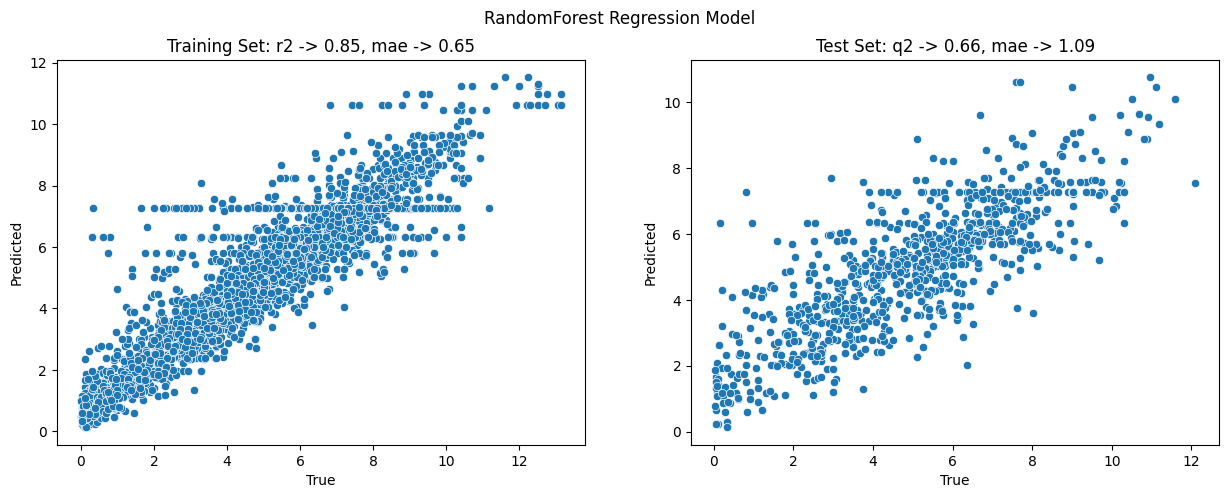

In [45]:
pipe, X_train, X_test, Y_train, Y_test = train_and_plot(morgan_df, pce)
comb_df, train_dict, test_dict = qsar.reg_results_df(pipe, X_train, X_test, Y_train, Y_test)

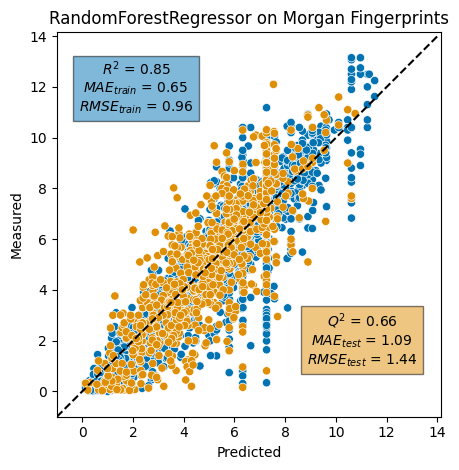

In [48]:
fig, ax = qsar.reg_results_viz_sns(comb_df, train_dict, test_dict, box_adjustment=0.15, title='RandomForestRegressor on Morgan Fingerprints')

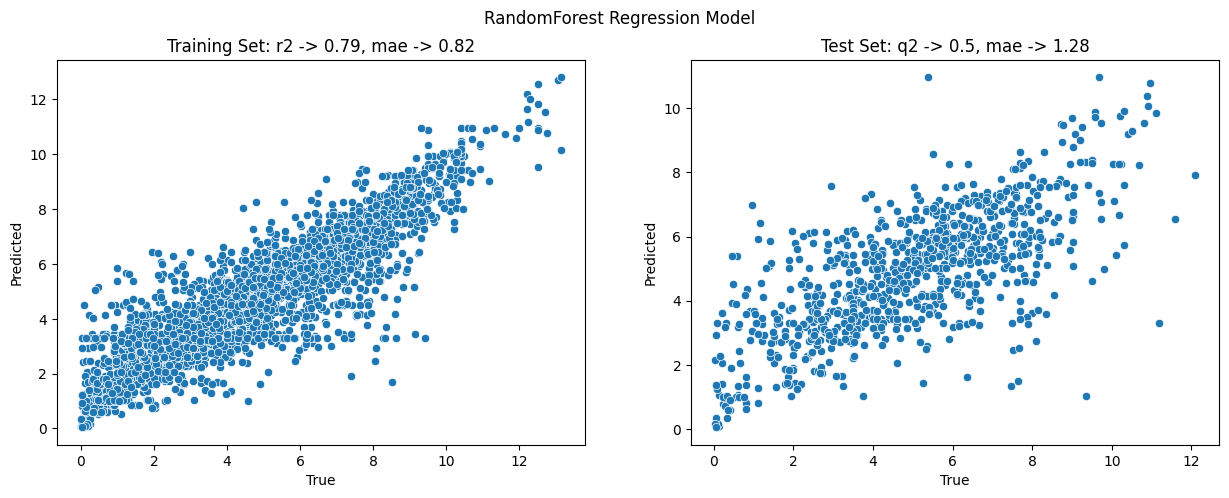

In [49]:
pipe, X_train, X_test, Y_train, Y_test = train_and_plot(sdfp, pce)
comb_df, train_dict, test_dict = qsar.reg_results_df(pipe, X_train, X_test, Y_train, Y_test)

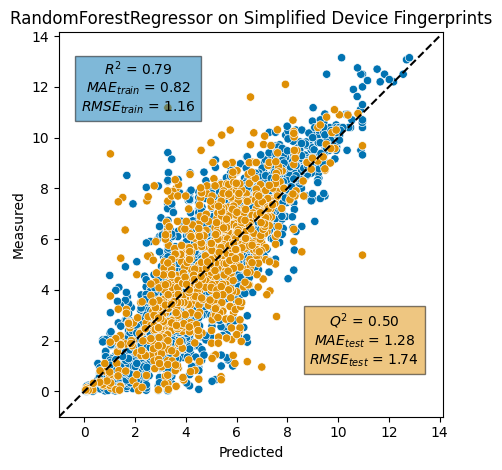

In [50]:
fig, ax = qsar.reg_results_viz_sns(comb_df, train_dict, test_dict, box_adjustment=0.15, title='RandomForestRegressor on Simplified Device Fingerprints')

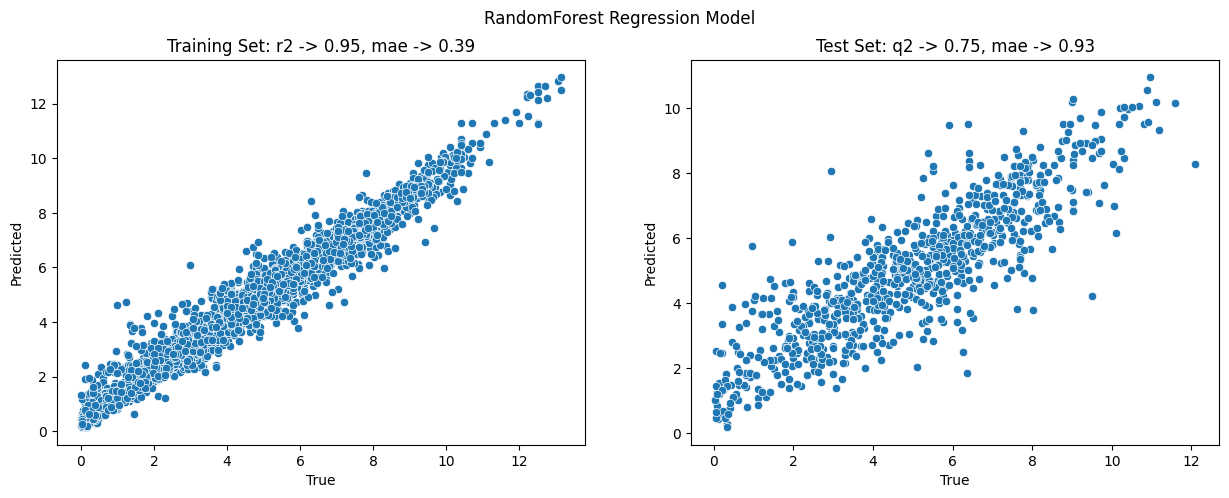

In [51]:
dye_device_desc = pd.concat([morgan_df, sdfp], axis=1)

pipe, X_train, X_test, Y_train, Y_test = train_and_plot(dye_device_desc, pce)
comb_df, train_dict, test_dict = qsar.reg_results_df(pipe, X_train, X_test, Y_train, Y_test)

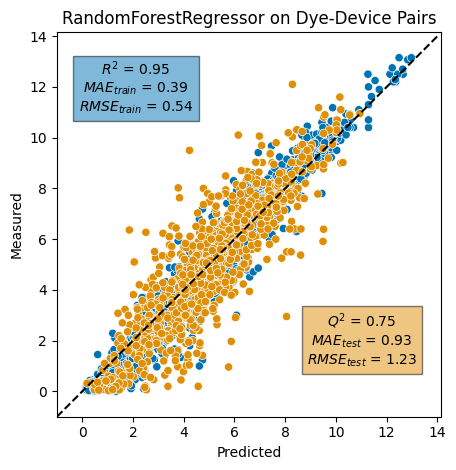

In [52]:
fig, ax = qsar.reg_results_viz_sns(comb_df, train_dict, test_dict, box_adjustment=0.15, title='RandomForestRegressor on Dye-Device Pairs')

In [53]:
dye_device_desc.to_csv('Data/dye_device_fp_not_imputed.csv')